In [17]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import time
import matplotlib.pyplot as plt
import numpy as np

# Calculate date range for the past month
end_date = datetime.now()
start_date = end_date - timedelta(days=30)

# Define tickers and add robust error handling for downloads
tickers = ["AAPL", "GOOG", "AMZN"]

# Function to download with retries
def download_with_retry(ticker, max_retries=3, delay=2):
    for attempt in range(max_retries):
        try:
            print(f"Downloading {ticker}, attempt {attempt+1}/{max_retries}")
            data = yf.download(
                ticker, 
                period="3mo", 
                auto_adjust=False, 
                interval='4h',
                progress=False
            )
            if not data.empty:
                return data
            else:
                print(f"Empty data for {ticker}, retrying...")
        except Exception as e:
            print(f"Error downloading {ticker}: {e}")
        
        # Wait before retry
        if attempt < max_retries - 1:
            print(f"Waiting {delay} seconds before retrying...")
            time.sleep(delay)
            delay *= 1.5  # Exponential backoff
    
    # If all retries fail, return empty DataFrame with correct columns
    print(f"Failed to download {ticker} after {max_retries} attempts")
    return pd.DataFrame(columns=['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'])

# Download Apple stock data with retry mechanism
aapl = download_with_retry("AAPL")

# Display the data if available
if not aapl.empty:
    print("\nSuccessfully downloaded AAPL data:")
    aapl.head()
else:
    print("Could not download AAPL data after multiple attempts")


Successfully downloaded AAPL data:


In [18]:
# Check if data is available before proceeding
if not aapl.empty:
    # Select adjusted close prices
    prices = aapl["Adj Close"]
    prices = prices.dropna()    # drop days where price is missing
    print("Price data:")
    print(prices.head())
    
    # Calculate returns
    if len(prices) > 1:  # Ensure we have enough data to calculate returns
        daily_returns = prices.pct_change().dropna()
        print(f"\nNumber of return observations: {daily_returns.count()}")
        print("\nReturn data:")
        print(daily_returns.head())
    else:
        print("Not enough data points to calculate returns")
else:
    print("No price data available for analysis")

Price data:
Ticker                           AAPL
Datetime                             
2025-02-24 14:30:00+00:00  248.050003
2025-02-24 18:30:00+00:00  247.229996
2025-02-25 14:30:00+00:00  247.979996
2025-02-25 18:30:00+00:00  247.050003
2025-02-26 14:30:00+00:00  240.340302

Number of return observations: Ticker
AAPL    127
dtype: int64

Return data:
Ticker                         AAPL
Datetime                           
2025-02-24 18:30:00+00:00 -0.003306
2025-02-25 14:30:00+00:00  0.003034
2025-02-25 18:30:00+00:00 -0.003750
2025-02-26 14:30:00+00:00 -0.027159
2025-02-26 18:30:00+00:00 -0.000126


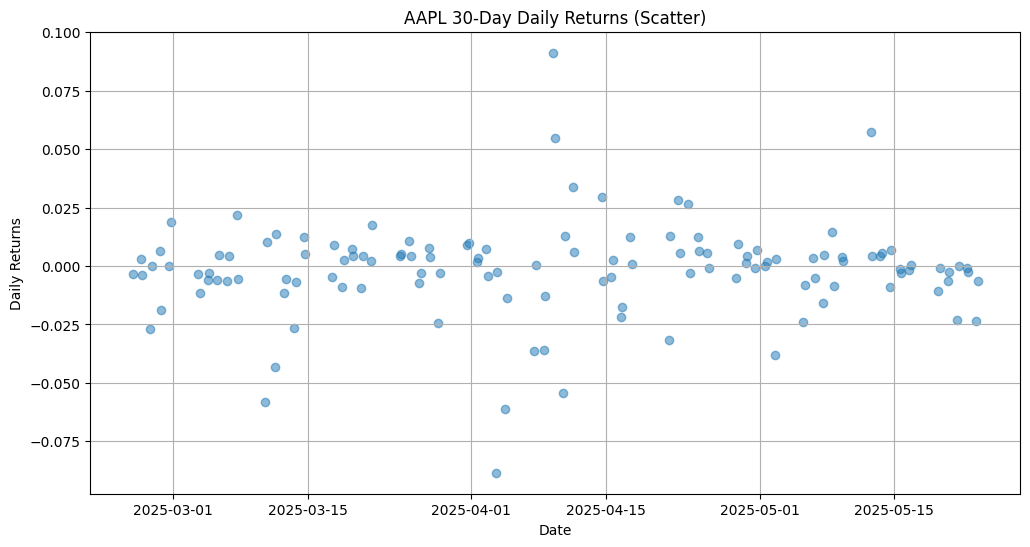

In [19]:
import matplotlib.pyplot as plt

# Only create the plot if we have data
try:
    if 'daily_returns' in locals() and not daily_returns.empty:
        plt.figure(figsize=(12,6))
        plt.scatter(daily_returns.index, daily_returns, alpha=0.5)
        plt.title('AAPL 30-Day Daily Returns (Scatter)')
        plt.xlabel('Date')
        plt.ylabel('Daily Returns')
        plt.grid(True)
        plt.show()
    else:
        print("No return data available for plotting")
except Exception as e:
    print(f"Error creating scatter plot: {e}")

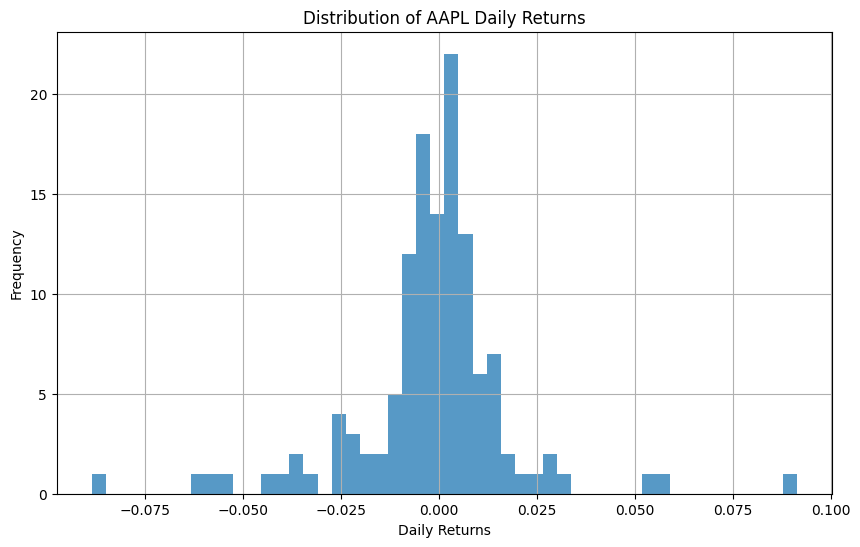

In [20]:
# Only create the histogram if we have data
try:
    if 'daily_returns' in locals() and not daily_returns.empty and len(daily_returns) >= 5:
        plt.figure(figsize=(10,6))
        plt.hist(daily_returns, bins=min(50, len(daily_returns)), alpha=0.75)
        plt.title('Distribution of AAPL Daily Returns')
        plt.xlabel('Daily Returns')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()
    else:
        print("Not enough return data for histogram (need at least 5 points)")
except Exception as e:
    print(f"Error creating histogram: {e}")

Error creating normal distribution plot: unsupported format string passed to Series.__format__


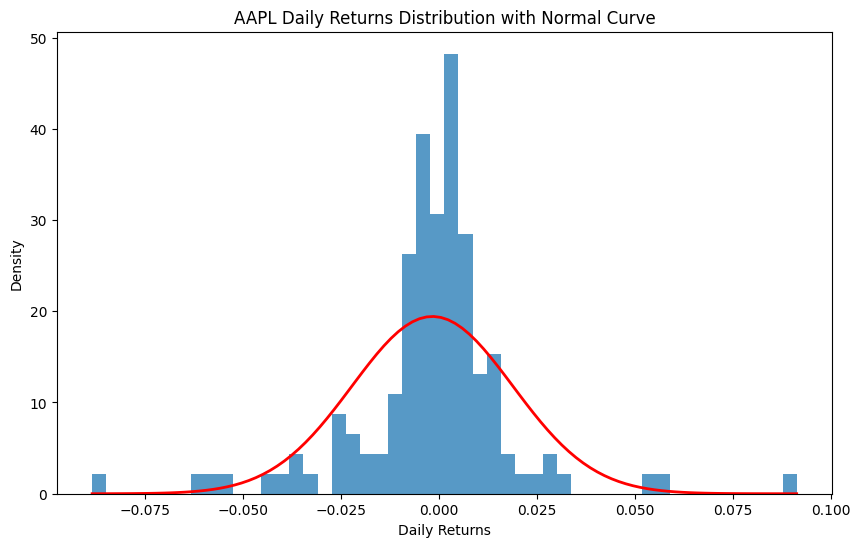

In [21]:
from scipy.stats import norm
import numpy as np

# Only create the normal distribution plot if we have enough data
try:
    if 'daily_returns' in locals() and not daily_returns.empty and len(daily_returns) >= 10:
        # Get the parameters for the normal distribution
        mu = daily_returns.mean()
        sigma = daily_returns.std()
        
        # Create points for the normal curve
        x = np.linspace(daily_returns.min(), daily_returns.max(), 100)
        normal_curve = norm.pdf(x, mu, sigma)
        
        # Plot histogram with normal curve overlay
        plt.figure(figsize=(10,6))
        plt.hist(daily_returns, bins=min(50, len(daily_returns)), density=True, alpha=0.75, label='Actual Returns')
        plt.plot(x, normal_curve, 'r-', lw=2, label='Normal Distribution')
        plt.title('AAPL Daily Returns Distribution with Normal Curve')
        plt.xlabel('Daily Returns')
        plt.ylabel('Density')
        
        # Add text box with μ and σ values
        plt.text(0.1, plt.gca().get_ylim()[1]*0.95, 
                 f'μ = {mu:.6f}\nσ = {sigma:.6f}', 
                 bbox=dict(facecolor='white', alpha=0.8))
        
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print("Not enough return data for normal distribution analysis (need at least 10 points)")
except Exception as e:
    print(f"Error creating normal distribution plot: {e}")

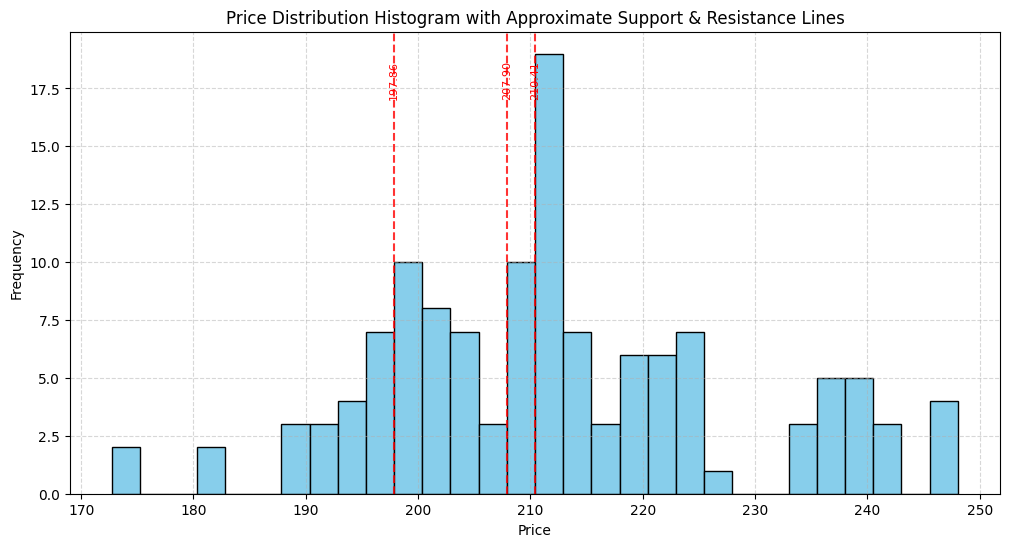

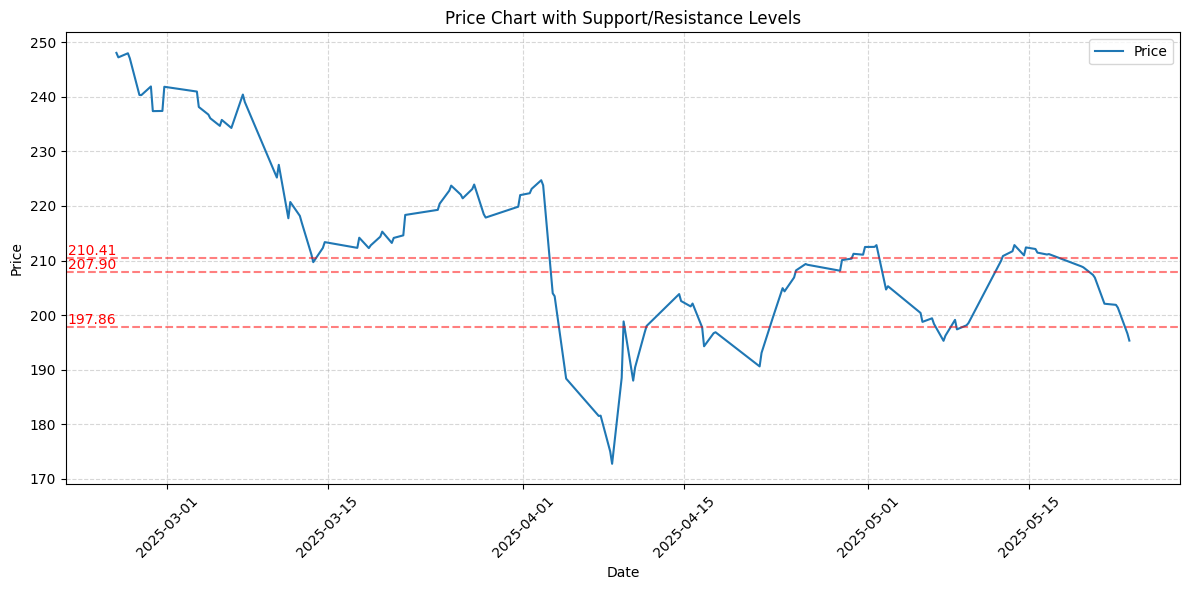

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Improved Explanation:
# Imagine a stock price chart, normally plotted with price (y-axis) against time (x-axis).
# Now, flip it sideways: Price becomes the horizontal (x-axis) and time becomes the vertical (y-axis).
# If the time dimension disappears, each price point drops vertically onto the horizontal price axis.
# These collected points form clusters at certain prices. By creating a histogram of these points,
# we visualize the distribution of prices, which helps us clearly identify support and resistance zones.

# Python script:

def plot_price_histogram(prices, bins=50):
    plt.figure(figsize=(12, 6))

    # Plot histogram
    counts, edges, patches = plt.hist(prices, bins=bins, orientation='vertical', color='skyblue', edgecolor='black')

    # Identify significant price levels (peaks in histogram)
    significant_levels = edges[np.argwhere(counts > np.percentile(counts, 90)).flatten()]

    # Plot support/resistance lines
    for level in significant_levels:
        plt.axvline(x=level, color='red', linestyle='--', alpha=0.8)
        plt.text(level, max(counts)*0.9, f'{level:.2f}', rotation=90, color='red', fontsize=8, ha='center')

    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.title('Price Distribution Histogram with Approximate Support & Resistance Lines')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    
    return significant_levels

# Example usage:
# Simulated price data
np.random.seed(42)
prices = aapl["Adj Close"].dropna().values


def plot_price_chart_with_levels(aapl, sLevel):
    # Plot price chart with support/resistance levels
    plt.figure(figsize=(12, 6))
    plt.plot(aapl.index, aapl['Adj Close'], label='Price')

    # Plot horizontal lines for significant levels
    for level in sLevel:
        plt.axhline(y=level, color='red', linestyle='--', alpha=0.5)
        plt.text(aapl.index[0], level, f'{level:.2f}', color='red', ha='right', va='bottom')

    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Price Chart with Support/Resistance Levels')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

sLevel = plot_price_histogram(prices, 30)
plot_price_chart_with_levels(aapl, sLevel)

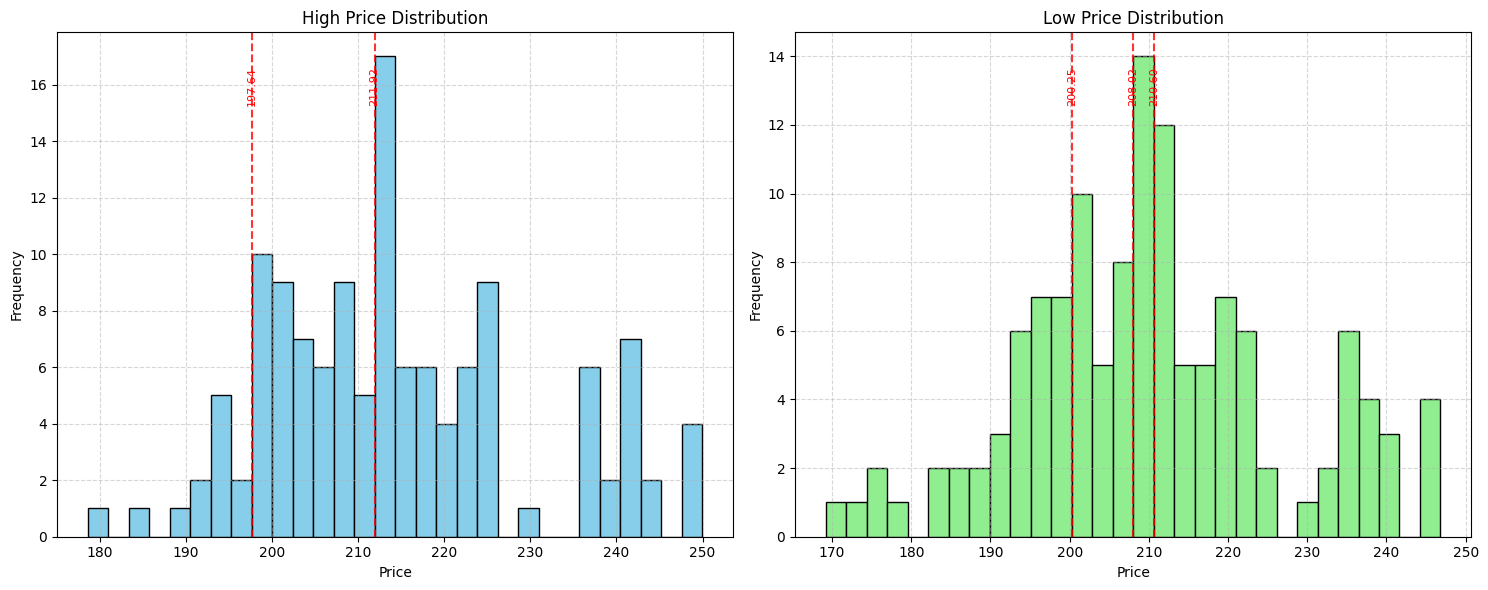

In [59]:
# now plot one for the high and the low price
# Create subplots for High and Low prices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot histogram for High prices
counts_high, edges_high, patches_high = ax1.hist(aapl['High'], bins=30, color='skyblue', edgecolor='black')
significant_levels_high = edges_high[np.argwhere(counts_high > np.percentile(counts_high, 90)).flatten()]
for level in significant_levels_high:
    ax1.axvline(x=level, color='red', linestyle='--', alpha=0.8)
    ax1.text(level, max(counts_high)*0.9, f'{level:.2f}', rotation=90, color='red', fontsize=8, ha='center')
ax1.set_title('High Price Distribution')
ax1.set_xlabel('Price')
ax1.set_ylabel('Frequency')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot histogram for Low prices
counts_low, edges_low, patches_low = ax2.hist(aapl['Low'], bins=30, color='lightgreen', edgecolor='black')
significant_levels_low = edges_low[np.argwhere(counts_low > np.percentile(counts_low, 90)).flatten()]
for level in significant_levels_low:
    ax2.axvline(x=level, color='red', linestyle='--', alpha=0.8)
    ax2.text(level, max(counts_low)*0.9, f'{level:.2f}', rotation=90, color='red', fontsize=8, ha='center')
ax2.set_title('Low Price Distribution')
ax2.set_xlabel('Price')
ax2.set_ylabel('Frequency')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [54]:
significant_levels_high.tolist() + significant_levels_low.tolist()

[198.5935223388672,
 200.02092437744142,
 211.44014068603516,
 212.8675427246094,
 222.8593569946289,
 197.14966552734376,
 206.46285461425782,
 209.5672509765625,
 211.11944915771485]

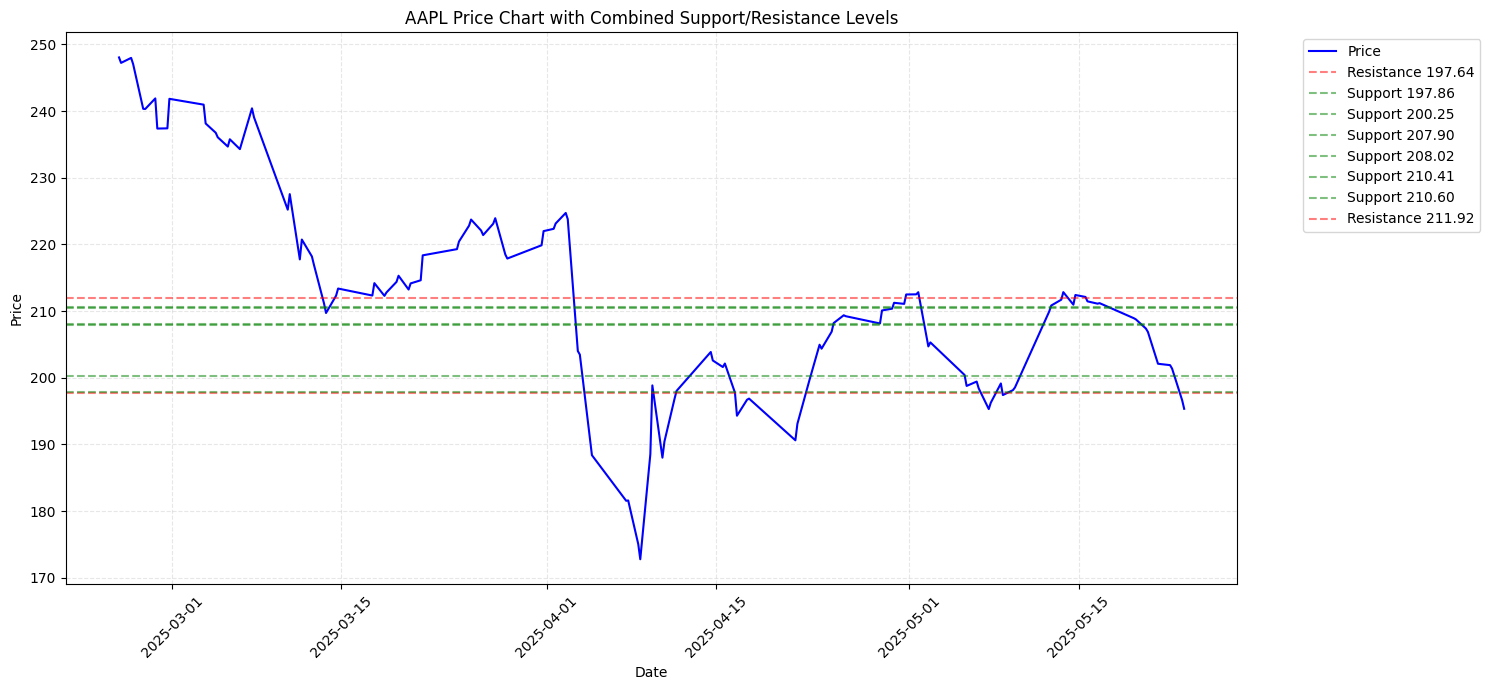

: 

In [ ]:
# Combine all significant levels and remove duplicates
all_levels = np.unique(np.concatenate([significant_levels_high, significant_levels_low, sLevel]))

# Plot price chart with all support/resistance levels
plt.figure(figsize=(15, 7))
plt.plot(aapl.index, aapl['Adj Close'], label='Price', color='blue')

# Plot horizontal lines for significant levels with different colors based on source
for level in all_levels:
    # Determine if level is from high, low, or both
    is_high = level in significant_levels_high
    is_low = level in significant_levels_low
    
    if is_high and is_low:
        color = 'purple'  # Both high and low
        label = f'Strong S/R {level:.2f}'
    elif is_high:
        color = 'red'     # High only
        label = f'Resistance {level:.2f}'
    else:
        color = 'green'   # Low only
        label = f'Support {level:.2f}'
    
    plt.axhline(y=level, color=color, linestyle='--', alpha=0.5, label=label)

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('AAPL Price Chart with Combined Support/Resistance Levels')
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
import yfinance as yf

info = yf.Ticker("AAPL").info     

In [5]:
info['currentPrice']

202.38